## Лабораторна робота 5. **CLASSIFICATION** 🔵/🔺

Оцінювання даної роботи буде ураховувати якість Ваших висновків та візуалізацій. При наявності ЛИШЕ коду та візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.  

Більшість поставлених в цій лабораторній роботі задач в майбутньому буде ставитись Вами самойстійно!

Під час виконання Вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Оформлення коментарів повинно проводитися в текстових комірках ноутбука з використанням синтаксису [LaTeX](https://en.wikibooks.org/wiki/LaTeX/Basics) для оформлення тексту та формул.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

# Опис вибірки "bank-additional-full"

   # Input variables:
   `bank client data:`  
   1 - **age** (numeric)  
   2 - **job** : type of job (categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")  
   3 - **marital** : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)  
   4 - **education** (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")  
   5 - **default**: has credit in default? (categorical: "no","yes","unknown")  
   6 - **housing**: has housing loan? (categorical: "no","yes","unknown")  
   7 - **loan**: has personal loan? (categorical: "no","yes","unknown")  
   # related with the last contact of the current campaign:  
   8 - **contact**: contact communication type (categorical: "cellular","telephone")   
   9 - **month**: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  10 - **day_of_week**: last contact day of the week (categorical: "mon","tue","wed","thu","fri")  
  11 - **duration**: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.  
   # other attributes:  
  12 - **campaign**: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  13 - **pdays**: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)  
  14 - **previous**: number of contacts performed before this campaign and for this client (numeric)
  15 - **poutcome**: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")  
   # social and economic context attributes  
  16 - **emp.var.rate**: employment variation rate - quarterly indicator (numeric)  
  17 - **cons.price.idx**: consumer price index - monthly indicator (numeric)       
  18 - **cons.conf.idx**: consumer confidence index - monthly indicator (numeric)       
  19 - **euribor3m**: euribor 3 month rate - daily indicator (numeric)  
  20 - **nr.employed**: number of employees - quarterly indicator (numeric)  
    
   `Output variable (desired target):`  
  21 - **y** - has the client subscribed a term deposit? (binary: "yes","no")

## Імпорт необхідних бібліотек та завантаження даних

**Завдання 1** підготовка даних до опрацювання

1. завантажте вибірку `bank-additional-full.csv`;   
2. підключіть необхідні бібліотеки;  
3. вивести основну статистичну інформацію по числовим змінним;  
4. вивести розмірність датасету.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset = pd.read_csv("sample_data/bank-additional-full.csv", sep=";")

infoNumberColumns = dataset.info()
print("Info about columns with numbers: \n", infoNumberColumns)

descrNumberColumns = dataset.describe()
print("Info about columns with numbers: \n", descrNumberColumns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Завдання 2** підготовка цільової змінної  

1. проаналізувати атрибути вибірки, визначити цільовий атрибут `target atribute`;
2. якщо `target atribute` є категоріальним, його необхідно перетворити в чисельний.

In [3]:
bank_target = "y"

print("Унікальні значення цільового атрибута:", dataset[bank_target].unique())

dataset[bank_target] = dataset[bank_target].map({"yes": 1, "no": 0})

print(dataset[bank_target].iloc[100:151])

Унікальні значення цільового атрибута: ['no' 'yes']
100    0
101    0
102    0
103    0
104    0
105    0
106    0
107    0
108    0
109    0
110    0
111    0
112    0
113    0
114    0
115    0
116    0
117    0
118    0
119    0
120    0
121    0
122    0
123    0
124    0
125    0
126    0
127    0
128    0
129    1
130    0
131    0
132    0
133    0
134    0
135    0
136    0
137    0
138    0
139    1
140    0
141    0
142    0
143    0
144    0
145    0
146    0
147    0
148    0
149    0
150    0
Name: y, dtype: int64


## Аналіз змінних, які характеризують клієнтів банку:

**Завдання 3** Визначитись зі всіма атрибутами, що характреризують кліентів банку:
- виділити їх в окрему частину;
- первірити всі змінні (які унікальні значення містять атрибути)(дивись опис датасету).

In [4]:
bank_client = ["age", "job", "marital", "education", "default", "housing", "loan"]
clients_df = dataset[bank_client]

**Завдання 4** Аналіз атрибуту `Age`:  
1. Вивести максимальне та мінімальне значення;  
2. Перевірити на наявність `NaN`;  
3. Провести візуальний аналіз зміної `Age`:
    - побудувати `countplot`, `boxplot`, `distplot`;
    - перевірити розподіл по змінній `Age` на важкі хвости.

Максимальний вік:  98
Мінімальний вік:  17

 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


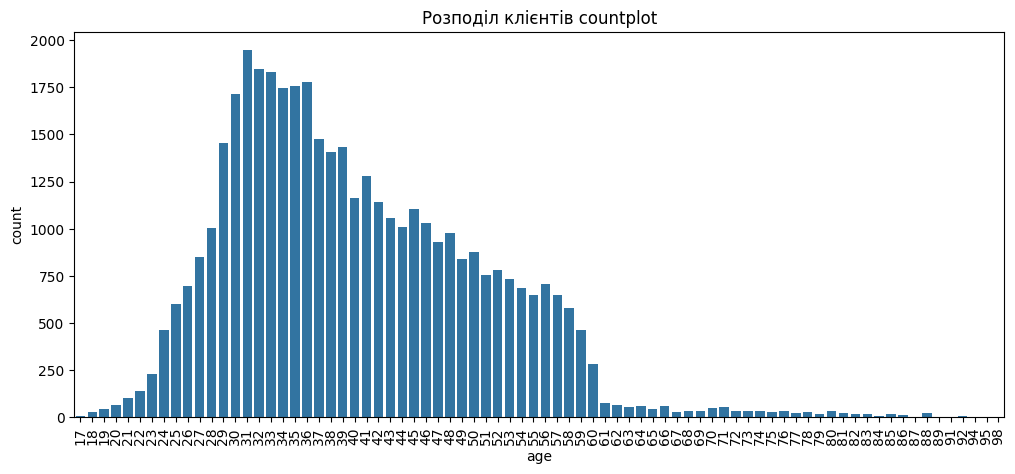

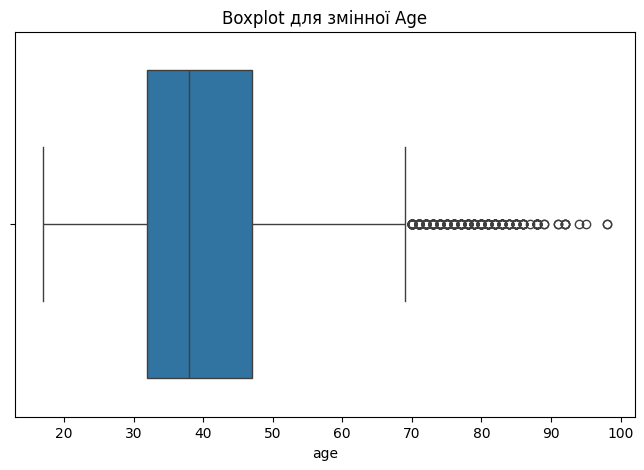

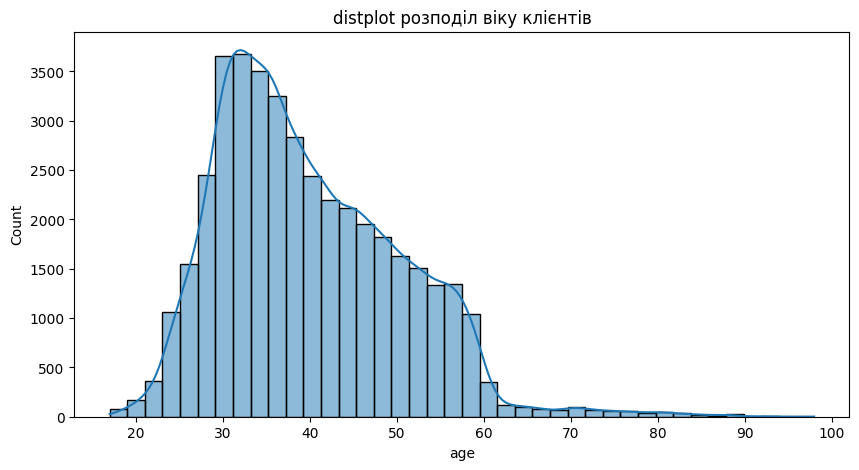

In [5]:
#code

datasetAgeMax = dataset["age"].max()
print("Максимальний вік: ",datasetAgeMax)

datasetAgeMin = dataset["age"].min()
print("Мінімальний вік: ",datasetAgeMin)

datasetCheckForNull = dataset.isnull().sum()
print("\n",datasetCheckForNull)

plt.figure(figsize=(12,5))
sns.countplot(x="age", data=dataset)
plt.xticks(rotation=90)
plt.title("Розподіл клієнтів countplot")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=dataset["age"])
plt.title("Boxplot для змінної Age")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(dataset["age"], kde=True, bins=40)
plt.title("distplot pозподіл віку клієнтів")
plt.show()

**Висновки з 1-4 завдання (детальні)**

1. Вata shows that the average age of the bank's customers is around 40 years, with the youngest being 17 and the oldest being 98. This indicates that the bank works with a wide age audience. The duration of telephone conversations varies significantly: in some cases the calls were short, while in others they lasted quite long, which may indicate the level of interest of the customers in the banking products. Most customers contacted the bank 1 or 2 times, but there are some who were contacted much more often.  
2. Here we see that our target is whether the client agreed or not, this is the factor we need to predict, these values ​​were classified into the corresponding digits 0 and 1. Among other things, it is noticeable that we have a lot of rejections
3. Here we select the data that can tell us the most about our client, namely data such as "age", "job", "marital", "education", "default", "housing", "loan"
4. Here we found the maximum and minimum age values ​​that we already knew from the first task. We can also see that we have no gaps. The countplot graph does not show any tails that would distort the data, the number of people by age smoothly increases and smoothly decreases. While the Boxplot shows us a box in which there are normal values, and behind it circles that show anomalies, that is, ages from 70 to 100, although this cannot be an anomaly... distplot also shows a smooth increase and decrease, with the largest number of 32 years and the smallest 90+

**Завдання 5** Перевірити атрибут `Age` на викиди:

In [6]:
def detect_outliers_with_interquantile_range(df: pd.DataFrame,
                                             column: str,
                                             low_percentile: int,
                                             high_percentile: int) -> pd.DataFrame:
    """
    Detecting outliers using interquantile range set manually

    df: pd.DataFrame to detect outliers
    column: target column
    low_percentile: lower bound between 0 and 100
    high_percentile: upper bound between 0 and 100

    returns: pd.DataFrame with detected outliers

    """
    sorted_data = np.sort(df[column])
    Q1 = np.percentile(sorted_data, low_percentile)
    Q3 = np.percentile(sorted_data, high_percentile)

    print('')
    print(f"Q1 {low_percentile} percentile of the given data: {Q1}")
    print('')

    print(f"Q3 {high_percentile} percentile of the given data: {Q3}")
    print('')
    print('----------------------------------------------------------')

    IQR = Q3 - Q1
    print('')
    print(f"Interquantile range: {IQR}")
    print('')
    print('----------------------------------------------------------')
    low_lim = Q1 - (1.5 * IQR)
    up_lim = Q3 + (1.5 * IQR)
    print('')
    print(f" Lower bound: {low_lim}")
    print('')
    print(f" Upper bound: {up_lim}")
    print('')
    print('----------------------------------------------------------')
    outliers = df[(df[column] > up_lim) | (df[column] < low_lim)]
    print('')
    print(f"Outliers in the dataset:")
    display(outliers)

    return outliers

In [7]:
outliers = detect_outliers_with_interquantile_range(clients_df, 'age', 10, 90)


Q1 10 percentile of the given data: 28.0

Q3 90 percentile of the given data: 55.0

----------------------------------------------------------

Interquantile range: 27.0

----------------------------------------------------------

 Lower bound: -12.5

 Upper bound: 95.5

----------------------------------------------------------

Outliers in the dataset:


,age,job,marital,education,default,housing,loan
38452,98,retired,married,basic.4y,unknown,yes,no
38455,98,retired,married,basic.4y,unknown,yes,no


**Висновки з завдання 5 (детальні)**

detect_outliers_with_interquantile_range – a function that detects outliers based on quartiles. low_percentile and high_percentile are the percentages that define the first quartile. i.e. 25% and the third quartile i.e. 75%, which are the boundaries of the main data range. Q1 and Q3 are the first quartile and (third quartile) respectively. IQR is the difference between Q3 and Q1, which defines the spread of the main data mass. low_lim – values ​​that are lower are considered outliers. up_lim – values ​​that are higher are considered outliers. outliers – values ​​that fall outside low_lim or up_lim.

The interquartile range (IQR) is 27 years, and the allowable age values ​​are in the range from -12.5 to 95.5 years. Two potential outliers were detected in the sample – customers aged 98, which may indicate anomalous values ​​or a special group of customers (for example, pensioners).

**Завдання 6** Аналіз атрибутів `job`, `marital` та `education`:  
- Побудувати графіки розподілу даних по цим змінним.

Text(0.5, 1.0, 'Графік розподілу даних за професіями')

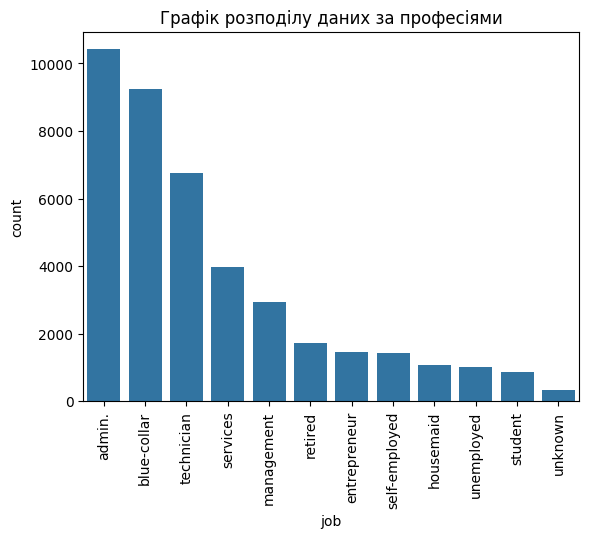

In [8]:
#code

sns.countplot(x=clients_df['job'], order=clients_df['job'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Графік розподілу даних за професіями")

Text(0.5, 1.0, 'Графік розподілу даних за сімейним статусом')

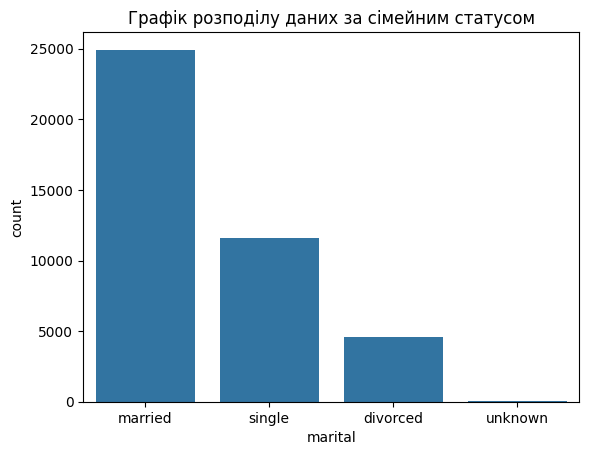

In [9]:
#code
sns.countplot(x=clients_df['marital'], order=clients_df['marital'].value_counts().index)
plt.title("Графік розподілу даних за сімейним статусом")

Text(0.5, 1.0, 'Графік розподілу даних за освітою')

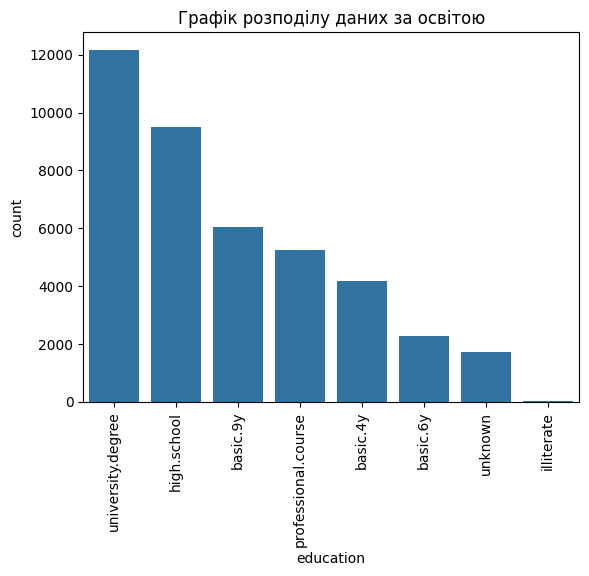

In [10]:
#code

sns.countplot(x=clients_df['education'], order=clients_df['education'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Графік розподілу даних за освітою")

**Висновки з завдання 6 (детальні)**

1. Using seaborn and countplot we see that among the three most popular professions are admin, blue collar, and technician or engineer
2. among family statuses the most popular is married
3. among all levels of education the most popular are university, college, and 9 years of study

**Завдання 7** Аналіз атрибутів `default`, `housing` та `loan`:  
- Побудувати графіки розподілу даних по цим змінним.

Text(0.5, 1.0, 'Кредит є у дефолті(тобто у боргу)')

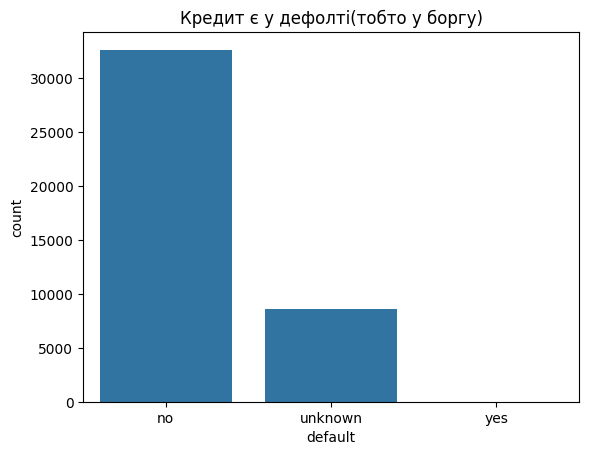

In [11]:
#code
sns.countplot(x=clients_df['default'], order=clients_df['default'].value_counts().index)
plt.title("Кредит є у дефолті(тобто у боргу)")

Text(0.5, 1.0, 'Будинок на позику')

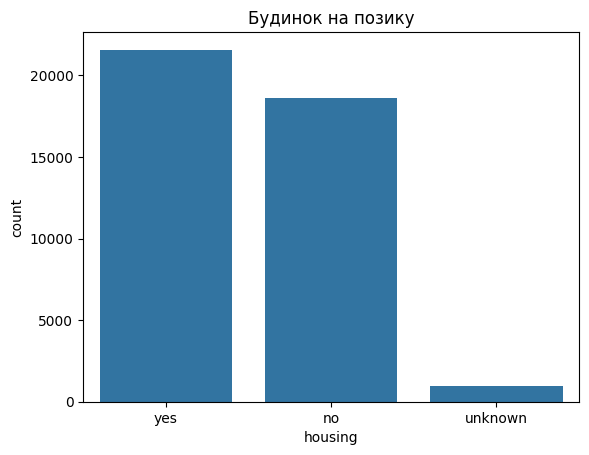

In [12]:
#code
sns.countplot(x=clients_df['housing'], order=clients_df['housing'].value_counts().index)
plt.title("Будинок на позику")

Text(0.5, 1.0, 'Має позики')

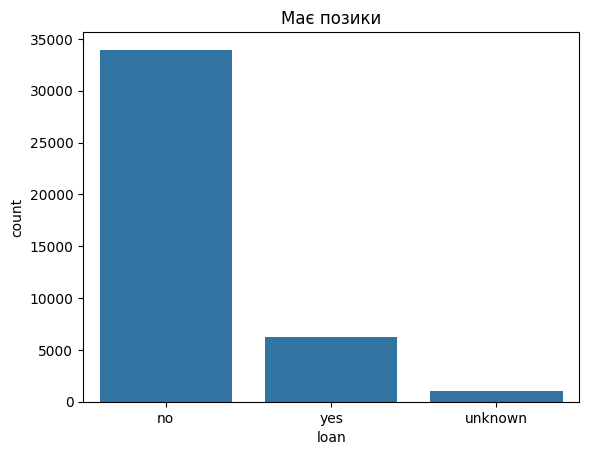

In [13]:
#code
sns.countplot(x=clients_df['loan'], order=clients_df['loan'].value_counts().index)
plt.title("Має позики")

**Завдання 8** Змінні **Jobs, Marital, Education, Default, Housing, Loan** трансформувати в неперервні змінні:

In [14]:
def encode_categorical_columns(df: pd.DataFrame, categorical_cols: list) -> pd.DataFrame:
    """
    Function for encoding categorical features using LabelEncoder

    df: pd.DataFrame to encode
    categorical_cols: specified columns to encode

    returns: pd.DataFrame with encoded values
    """
    for col in categorical_cols:
      # Leaves NaN as it is.
        le = LabelEncoder()
        not_null = df[col][df[col].notnull()]
        df.loc[df[col].notnull(), col] = le.fit_transform(not_null)

    return df

In [15]:
bank_client = encode_categorical_columns(clients_df, ['job', 'marital', 'education', 'default', 'housing',  'loan'])

**Завдання 9** Трансфомувати змінну **Age** (використовуючи її квартильні значення):




In [16]:
def encode_age(dataframe: pd.DataFrame, age_col: str ) -> pd.DataFrame:
  """
  Function for encoding age column

  df: pd.DataFrame to encode
  age_col: age col to encode
  """
  q1 = dataframe[age_col].quantile(0.25)
  q2 = dataframe[age_col].quantile(0.50)
  q3 = dataframe[age_col].quantile(0.75)

  dataframe['age'] = pd.cut(dataframe[age_col], bins=[dataframe[age_col].min(), q1, q2, q3, dataframe[age_col].max()], labels=[1, 2, 3, 4], include_lowest=True) #labels=["youngest", "young", "old", "oldest"])


  return dataframe

In [17]:
bank_client = encode_age(clients_df, 'age')
print(bank_client.head(30))


   age job marital education default housing loan
0    4   3       1         0       0       0    0
1    4   7       1         3       1       0    0
2    2   7       1         3       0       2    0
3    3   0       1         1       0       0    0
4    4   7       1         3       0       0    2
5    3   7       1         2       1       0    0
6    4   0       1         5       0       0    0
7    3   1       1         7       1       0    0
8    1   9       2         5       0       2    0
9    1   7       2         3       0       2    0
10   3   1       1         7       1       0    0
11   1   7       2         3       0       2    0
12   1   1       2         3       0       0    2
13   4   3       0         0       0       2    0
14   2   1       1         1       0       2    0
15   4   5       1         2       1       2    2
16   2   1       1         1       0       2    0
17   3   1       1         1       1       2    2
18   4   1       1         2       0       2    2


**Висновки з завдання 9 (детальні)** перевірити як відбулося перетворення змінних

Трансформація змінного віку на категоріальні групи за допомогою квартилів дозволила поділити дані на чітко визначені вікові категорії («наймолодший», «молодий», «старий», «старший»), що забезпечує кращу узагальненість при аналізі та моделюванні. Це дозволяє зменшити вплив відхилених значень і спрощує класифікацію за віковими групами, водночас зберігаючи значення, які дають корисну інформацію про розподіл віку серед клієнтів.

## Вибірка містить певну кількість атрибутів, які характеризують останій зв'язок кліентів з банком

**Завдання 10** Виділити в окремий датафрейм змінні, які характеризують зв'язок клієнтів з банком;
- вивести цей датафрейм;
- перевірити ці змінні на `NaN`.

In [18]:
bank_relat = dataset[['contact', 'month', 'day_of_week', 'duration']]
print(bank_relat.head())

print("\nПеревірка на NaN: ")
print(bank_relat.isna().sum())

     contact month day_of_week  duration
0  telephone   may         mon       261
1  telephone   may         mon       149
2  telephone   may         mon       226
3  telephone   may         mon       151
4  telephone   may         mon       307

Перевірка на NaN: 
contact        0
month          0
day_of_week    0
duration       0
dtype: int64


**Завдання 11** вивести унікальні значення, які містять атрибути `contact`, `month`, `day_of_week`

In [19]:
#code
print(bank_relat['contact'].unique())

print(bank_relat['month'].unique())

print(bank_relat['day_of_week'].unique())

['telephone' 'cellular']
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
['mon' 'tue' 'wed' 'thu' 'fri']


# Провести аналіз змінної **Duration**

змінна ` duration` містить інформацію про тривалість останнього дзвінка, в секундах (числова). Важливе зауваження: цей атрибут сильно впливає на цільову змінну (наприклад, якщо тривалість = 0, тоді y = "ні"). Проте тривалість невідома до здійснення дзвінка. Крім того, після закінчення дзвінка y, очевидно, відомо. Таким чином, цей внесок слід включати лише для цілей порівняльних показників і відкидати, якщо метою є реалістична модель прогнозування.

**Завдання 12** Аналіз атрибуту `duration`:  

Провести візуальний аналіз зміної `duration`:  


*   побудувати  `boxplot` та `distplot`;
*   перевірити розподіл по змінній `duration` на важкі хвости.



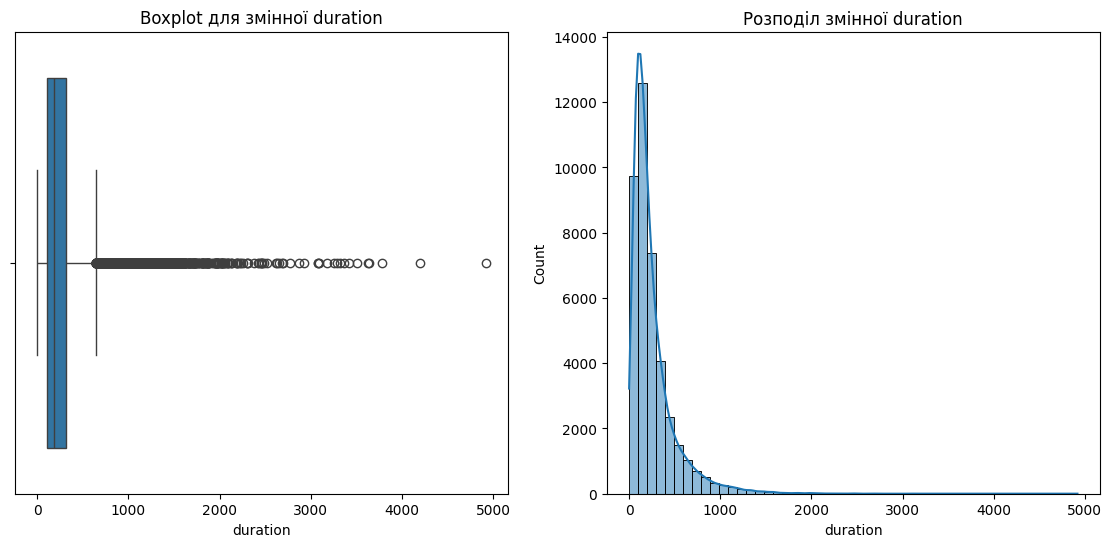

In [20]:
#code
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=bank_relat['duration'])
plt.title("Boxplot для змінної duration")

plt.subplot(1, 2, 2)
sns.histplot(bank_relat['duration'], kde=True, bins=50)
plt.title("Розподіл змінної duration")

plt.show()

**Завдання 13** Закодувати змінні Contact, Month, Day of Week (використовуйте функцію `encode_categorical_columns()`)

In [21]:
#code
bank_relat = encode_categorical_columns(bank_relat, ['contact', 'month', 'day_of_week'])
print(bank_relat.head(20))

   contact month day_of_week  duration
0        1     6           1       261
1        1     6           1       149
2        1     6           1       226
3        1     6           1       151
4        1     6           1       307
5        1     6           1       198
6        1     6           1       139
7        1     6           1       217
8        1     6           1       380
9        1     6           1        50
10       1     6           1        55
11       1     6           1       222
12       1     6           1       137
13       1     6           1       293
14       1     6           1       146
15       1     6           1       174
16       1     6           1       312
17       1     6           1       440
18       1     6           1       353
19       1     6           1       195


**Завдання 14** Трансфомувати змінну **duration**, використовуючи її квартильні значення:

In [22]:
def encode_duration(dataframe: pd.DataFrame, duration_col: str ) -> pd.DataFrame:
  """
  Function for encoding duration column

  df: pd.DataFrame to encode
  duration_col: duration col to encode
  """

  #code
  q1 = dataframe[duration_col].quantile(0.25)
  q2 = dataframe[duration_col].quantile(0.50)
  q3 = dataframe[duration_col].quantile(0.75)

  dataframe['duration'] = pd.cut(dataframe[duration_col], bins=[dataframe[duration_col].min(), q1, q2, q3, dataframe[duration_col].max()], labels=[1, 2, 3, 4], include_lowest=True) #labels=["shortest", "short", "long", "longest"]

  return dataframe

In [23]:
bank_relat = encode_duration(bank_relat, 'duration')
print(bank_relat.head(20))
print(bank_relat.isnull().sum())

   contact month day_of_week duration
0        1     6           1        3
1        1     6           1        2
2        1     6           1        3
3        1     6           1        2
4        1     6           1        3
5        1     6           1        3
6        1     6           1        2
7        1     6           1        3
8        1     6           1        4
9        1     6           1        1
10       1     6           1        1
11       1     6           1        3
12       1     6           1        2
13       1     6           1        3
14       1     6           1        2
15       1     6           1        2
16       1     6           1        3
17       1     6           1        4
18       1     6           1        4
19       1     6           1        3
contact        0
month          0
day_of_week    0
duration       0
dtype: int64


## Провести аналіз атрибутів **соціального та економічного контексту**

**Завдання 15** Виділити в окремий датафрейм атрибути соціального та єкономічного контексту

In [24]:
bank_socec = dataset[['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']]
print(bank_socec.head())

   emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
0           1.1          93.994          -36.4      4.857       5191.0
1           1.1          93.994          -36.4      4.857       5191.0
2           1.1          93.994          -36.4      4.857       5191.0
3           1.1          93.994          -36.4      4.857       5191.0
4           1.1          93.994          -36.4      4.857       5191.0


**Завдання 16** Виділити в окремий датафрейм всі інші атрибути атрибути - `campaign`, `pdays`,`previous`, `poutcome`

In [25]:
bank_other = dataset[['campaign', 'pdays', 'previous', 'poutcome',]]
print(bank_other.head())

   campaign  pdays  previous     poutcome
0         1    999         0  nonexistent
1         1    999         0  nonexistent
2         1    999         0  nonexistent
3         1    999         0  nonexistent
4         1    999         0  nonexistent


**Завдання 17** Провести трансформацію атрибуту `poutcome`

In [26]:
#code
def encode_poutcome(dataframe: pd.DataFrame, poutcome_col: str) -> pd.DataFrame:

    """
    Function for encoding poutcome column.

    dataframe: pd.DataFrame to encode
    poutcome_col: poutcome column to encode
    """

    dataframe['poutcome'] = dataframe[poutcome_col].map({'failure': 0, 'nonexistent': 1, 'success': 2})

    return dataframe
encoded_poutcome = encode_poutcome(bank_other, 'poutcome')
print(encoded_poutcome)

       campaign  pdays  previous  poutcome
0             1    999         0         1
1             1    999         0         1
2             1    999         0         1
3             1    999         0         1
4             1    999         0         1
...         ...    ...       ...       ...
41183         1    999         0         1
41184         1    999         0         1
41185         2    999         0         1
41186         1    999         0         1
41187         3    999         1         0

[41188 rows x 4 columns]


## Будування моделей класифікації

**Завдання 18** З'єднати всі отримані блоки в один датафрейм і перевірити, що він містить тільки потрібні для моделювання колонки

In [27]:
bank_final = pd.concat([clients_df, bank_relat, bank_socec, bank_other], axis=1)
print(bank_final.head(5))



print(bank_final.isnull().sum())

  age job marital education default housing loan contact month day_of_week  \
0   4   3       1         0       0       0    0       1     6           1   
1   4   7       1         3       1       0    0       1     6           1   
2   2   7       1         3       0       2    0       1     6           1   
3   3   0       1         1       0       0    0       1     6           1   
4   4   7       1         3       0       0    2       1     6           1   

  duration  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
0        3           1.1          93.994          -36.4      4.857   
1        2           1.1          93.994          -36.4      4.857   
2        3           1.1          93.994          -36.4      4.857   
3        2           1.1          93.994          -36.4      4.857   
4        3           1.1          93.994          -36.4      4.857   

   nr.employed  campaign  pdays  previous  poutcome  
0       5191.0         1    999         0         1  
1 

**Завдання 19** Провести ділення вибірки

In [28]:
def prepare_data_for_training(X: pd.DataFrame,
                              target: pd.Series,
                              test_size: float,
                              n_splits: int,
                              random_state: int):
    """
    Function that prepares data for training. Splits the data into train and test datasets and get k-folds for cross-validation

    X: pd.DataFrame with features
    target: target pd.Series
    test_size: the size of test datasets
    n_splits: number of cross-validation splits
    random_state: random state to reproduce the same split

    returns: X_train, X_test, y_train, y_test, k_fold
    """

    X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=test_size, random_state=random_state)
    k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    return X_train, X_test, y_train, y_test, k_fold

In [29]:
X_train, X_test, y_train, y_test, k_fold = prepare_data_for_training(bank_final, dataset[bank_target], 0.2, 10, 101)

In [30]:
def scale_the_data(X_train: pd.DataFrame,
                   X_test: pd.DataFrame):

  sc_X = StandardScaler()
  X_train = sc_X.fit_transform(X_train)
  X_test = sc_X.transform(X_test)

  return X_train, X_test

In [31]:
X_train, X_test = scale_the_data(X_train, X_test)




## Логістична Регресія

In [32]:
logmodel = LogisticRegression()

logmodel.fit(X_train, y_train)
logpred = logmodel.predict(X_test)


print(confusion_matrix(y_test, logpred))
print(round(accuracy_score(y_test, logpred),2)*100)
LOGCV = (cross_val_score(logmodel, X_test, y_test, cv=k_fold, n_jobs=1, scoring = 'accuracy').mean())

[[7110  169]
 [ 633  326]]
90.0


## k-NN

k=1 86.80 (+/- 0.41)
k=2 89.33 (+/- 0.50)
k=3 88.99 (+/- 0.44)
k=4 89.83 (+/- 0.50)
k=5 89.75 (+/- 0.70)
k=6 90.23 (+/- 0.57)
k=7 90.12 (+/- 0.65)
k=8 90.35 (+/- 0.54)
k=9 90.32 (+/- 0.70)
k=10 90.42 (+/- 0.57)
k=11 90.40 (+/- 0.64)
k=12 90.39 (+/- 0.57)
k=13 90.44 (+/- 0.65)
k=14 90.42 (+/- 0.64)
k=15 90.50 (+/- 0.66)
k=16 90.50 (+/- 0.66)
k=17 90.53 (+/- 0.64)
k=18 90.53 (+/- 0.64)
k=19 90.53 (+/- 0.67)
k=20 90.51 (+/- 0.64)
k=21 90.55 (+/- 0.70)
k=22 90.53 (+/- 0.61)
k=23 90.53 (+/- 0.66)
k=24 90.55 (+/- 0.63)
k=25 90.56 (+/- 0.61)
The optimal number of neighbors is 24 with 90.6%


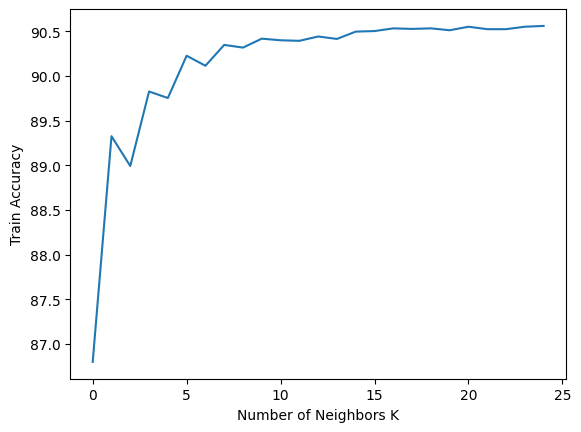

In [33]:
#Neighbors
neighbors = np.arange(0,25)

#Create empty list that will hold cv scores
cv_scores = []

#Perform 10-fold cross validation on training set for odd values of k:
for k in neighbors:
    k_value = k+1
    knn = KNeighborsClassifier(n_neighbors = k_value, weights='uniform', p=2, metric='euclidean')
    scores = model_selection.cross_val_score(knn, X_train, y_train, cv=k_fold, scoring='accuracy')
    cv_scores.append(scores.mean()*100)
    print("k=%d %0.2f (+/- %0.2f)" % (k_value, scores.mean()*100, scores.std()*100))

optimal_k = neighbors[cv_scores.index(max(cv_scores))]
print ("The optimal number of neighbors is %d with %0.1f%%" % (optimal_k, cv_scores[optimal_k]))

plt.plot(neighbors, cv_scores)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Train Accuracy')
plt.show()

In [34]:
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
knnpred = knn.predict(X_test)

print(confusion_matrix(y_test, knnpred))
print(round(accuracy_score(y_test, knnpred),2)*100)
KNNCV = (cross_val_score(knn, X_test, y_test, cv=k_fold, n_jobs=1, scoring = 'accuracy').mean())

[[7167  112]
 [ 708  251]]
90.0


## Логістична Регресія

In [37]:

logmodel = LogisticRegression()
log_cv_scores = cross_val_score(logmodel, X_train, y_train, cv=k_fold, scoring='accuracy')

knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn_cv_scores = cross_val_score(knn, X_train, y_train, cv=k_fold, scoring='accuracy')

models = pd.DataFrame({
    'Models': ['Logistic Regression', 'k-NN'],
    'Score': [log_cv_scores.mean() * 100, knn_cv_scores.mean() * 100]
})

models_sorted = models.sort_values(by='Score', ascending=False)

print(models_sorted)

                Models      Score
0  Logistic Regression  90.701062
1                 k-NN  90.552352


**Висновки по моделям (детальні)**

1.   Logistic regression showed an accuracy of 90.7%, indicating its effectiveness in classification problems with linear or approximate linear dependencies between variables. This model is well suited for situations where there is a clear and predictable relationship between the input features and the target variable, making it reliable for many types of tasks.

2.   The k-NN model with the optimal number of neighbors showed an accuracy of 90.6%, indicating its ability to adapt to more complex, nonlinear relationships in the data. Since it works on the basis of similarity between samples, its accuracy can vary depending on the choice of the value of k and the specificity of the data, which also makes it useful for more complex or fuzzy classifications.